In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Shared telescope geometry, the danish-based donut simulator, and figure
# helpers live in the installed `shape_vs_intensity` package (pip install -e .).
import danish  # noqa: F401
from shape_vs_intensity import config as C
from shape_vs_intensity import sim

# Match the repo's Computer-Modern figure style (but keep an interactive backend
# so the donuts render inline in the notebook).
REPO = C.FIGDIR.parent
mpl.rc_file(REPO / "matplotlibrc")
mpl.rcParams["backend"] = "module://matplotlib_inline.backend_inline"

# --- Shared figure geometry ----------------------------------------------
# The map_circles schematics use a frame half-width of DIAGRAM_L with an outer
# ring radius of 1, so the ring fills 1 / DIAGRAM_L of the panel.  We crop the
# simulated donuts to the same fraction (see show_donut) so the two rows match.
DIAGRAM_L = 1.25  # map_circles frame half-width (outer ring radius = 1)
DONUT_OUTER_PX = 66.7  # measured outer radius of a full-defocus donut, in pixels
ARCSEC_PER_PX = C.PIXEL_SCALE / C.FOCAL_LENGTH * 206265  # plate scale


def show_donut(ax, img):
    """Show a donut on ``ax``, cropped to match the schematic framing.

    Crops so a full-defocus ring fills the same fraction of the panel as the
    map_circles schematic ring (outer radius / half-width = 1 / DIAGRAM_L), then
    hides the axis ticks.
    """
    crop = C.NPIX // 2 - int(round(DONUT_OUTER_PX * DIAGRAM_L))
    ax.imshow(img[crop:-crop, crop:-crop], origin="lower")
    ax.set(xticks=[], yticks=[])


In [2]:
def map_circles(A, m, displacement, N=5, ax=None, center=True, **kwargs):
    """Map concentric pupil circles through a displacement field.

    Parameters
    ----------
    A : float
        Scale factor applied to the displacement.
    m : int
        Azimuthal order passed to ``displacement``.
    displacement : callable
        Function ``displacement(rho, theta, m) -> (dx, dy)`` in outer-pupil-radius units.
    N : int, optional
        Number of pupil circles to draw.
    ax : matplotlib.axes.Axes, optional
        Axes on which to draw the circles.
    center : bool, optional
        If True, center the view on the mapped circles.
    **kwargs
        Additional keyword arguments passed to ``Axes.plot``.
    """
    kwargs = {"c": "C1", "lw": 0.5, "zorder": 10} | kwargs
    if ax is None:
        fig, ax = plt.subplots()

    theta = np.linspace(0, 2 * np.pi, 10_000)
    for r in np.linspace(C.EPS_RUBIN, 1, N):
        rho = r * np.ones_like(theta)
        x0 = rho * np.cos(theta)
        y0 = rho * np.sin(theta)
        dx, dy = displacement(rho, theta, m)
        ax.plot(x0 + A * dx, y0 + A * dy, **kwargs)

    if center:
        x0 = np.mean(ax.get_xlim())
        y0 = np.mean(ax.get_ylim())
    else:
        x0, y0 = 0, 0
    ax.set(
        xlim=(x0 - DIAGRAM_L, x0 + DIAGRAM_L),
        ylim=(y0 - DIAGRAM_L, y0 + DIAGRAM_L),
        aspect="equal",
        xticks=[],
        yticks=[],
    )


def polar_displacement_to_xy(rho, theta, drho, dtheta):
    """Convert polar displacement components to Cartesian components.

    Parameters
    ----------
    rho, theta : array_like
        Polar coordinates of the sample points.
    drho, dtheta : array_like or float
        Radial and tangential displacement components.

    Returns
    -------
    dx, dy : ndarray
        Cartesian displacement components.
    """
    dx = drho * np.cos(theta) - dtheta * np.sin(theta)
    dy = drho * np.sin(theta) + dtheta * np.cos(theta)
    return dx, dy


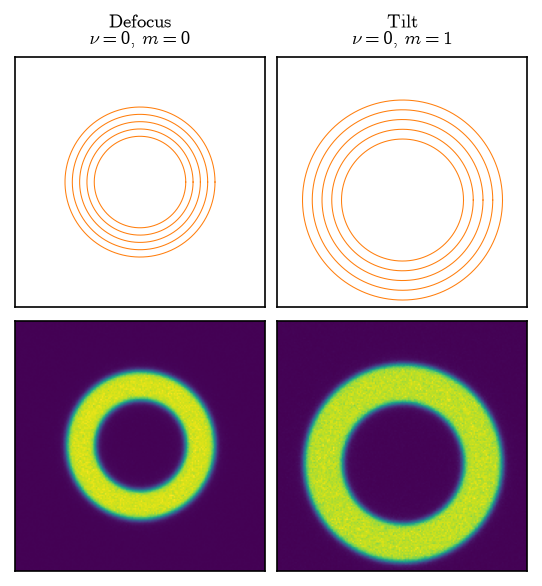

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(3.5, 3.8), constrained_layout=True, dpi=150)

axes[0, 0].set_title("Defocus\n$\\nu = 0,\\, m=0$")
axes[0, 1].set_title("Tilt\n$\\nu = 0,\\, m=1$")

# --- Top row: wavefront-circle schematics --------------------------------
# Defocus (m=0): a purely radial rescaling of the pupil circles (here a 25%
# shrink, A=0.25).  Tilt (m=1): a rigid lateral shift, no size change.  The
# tilt perturbation below shifts every circle straight down by 0.18 of the
# outer radius.
DEFOCUS_SHRINK = 0.25  # radial shrink used in the defocus schematic
TILT_SHIFT = 0.18  # downward shift of the tilt schematic, in outer-radius units

defocus_displacement = lambda rho, theta, m: polar_displacement_to_xy(
    rho, theta, -rho, 0
)
map_circles(DEFOCUS_SHRINK, 0, defocus_displacement, ax=axes[0, 0])

tilt_displacement = lambda rho, theta, m: (np.zeros_like(rho), -np.ones_like(rho))
map_circles(TILT_SHIFT, 0, tilt_displacement, ax=axes[0, 1], center=False)

# --- Bottom row: simulated extra-focal donuts ----------------------------
# Each donut shows its mode's signature.  Defocus sets the ring *size*: the
# defocus panel uses less absolute defocus so its ring is smaller (shrunk by the
# same (1 - DEFOCUS_SHRINK) factor as the schematic above), shown centred.  Tilt
# leaves the size unchanged but *shifts* the ring straight down, matching the
# tilt schematic (its circles shift by TILT_SHIFT of the outer radius in -y).
donut_defocus = sim.simulate_donut(defocus=(1 - DEFOCUS_SHRINK) * C.DEFOCUS_Z4)
donut_tilt = sim.simulate_donut(
    dy=-TILT_SHIFT * DONUT_OUTER_PX * ARCSEC_PER_PX
)

show_donut(axes[1, 0], donut_defocus)
show_donut(axes[1, 1], donut_tilt)

fig.savefig("../figures/abberations_defocus_tilt.pdf", bbox_inches="tight")


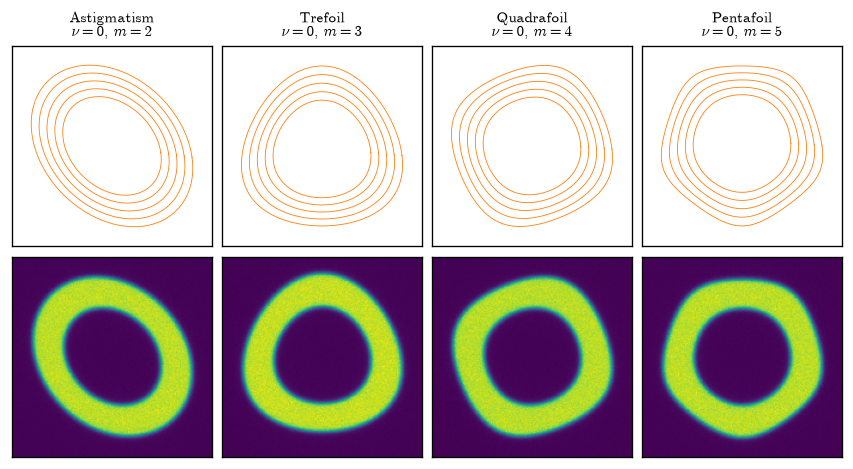

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(7, 3.8), constrained_layout=True, dpi=120)

axes[0, 0].set_title("Astigmatism\n$\\nu = 0,\\, m=2$")
axes[0, 1].set_title("Trefoil\n$\\nu = 0,\\, m=3$")
axes[0, 2].set_title("Quadrafoil\n$\\nu = 0,\\, m=4$")
axes[0, 3].set_title("Pentafoil\n$\\nu = 0,\\, m=5$")

# --- Top row: wavefront-circle schematics --------------------------------
# A donut is the pupil imaged through the wavefront slope: a ray leaving pupil
# point (u, v) lands displaced by the transverse ray aberration, -grad(W).  For
# an m-foil W = rho^m sin(m theta) the Cartesian gradient is
#   grad(W) = m rho^(m-1) (sin((m-1) theta), cos((m-1) theta)),
# so we displace each pupil circle by -grad(W).  Because the donuts below are
# extra-focal (upright) images, this one mapping matches every mode -- no
# per-mode sign flips needed (see simulate_donut for the extra-focal choice).
mfoil_displacement = lambda rho, theta, m: (
    -m * rho**(m - 1) * np.sin((m - 1) * theta),
    -m * rho**(m - 1) * np.cos((m - 1) * theta),
)

map_circles(0.070, 2, mfoil_displacement, ax=axes[0, 0])
map_circles(0.020, 3, mfoil_displacement, ax=axes[0, 1])
map_circles(0.010, 4, mfoil_displacement, ax=axes[0, 2])
map_circles(0.007, 5, mfoil_displacement, ax=axes[0, 3])

# --- Bottom row: simulated extra-focal donuts ----------------------------
# One donut per mode, each with the lowest Noll index of that azimuthal order
# (astigmatism Z5, trefoil Z9, quadrafoil Z15, pentafoil Z21) added to the
# baseline defocus.  The aberration imprints its m-fold shape on the donut.
show_donut(axes[1, 0], sim.simulate_donut(zernikes={5: 7e-6}))
show_donut(axes[1, 1], sim.simulate_donut(zernikes={9: 2e-6}))
show_donut(axes[1, 2], sim.simulate_donut(zernikes={15: 1e-6}))
show_donut(axes[1, 3], sim.simulate_donut(zernikes={21: 0.5e-6}))

fig.savefig("../figures/abberations_astig_mfoil.pdf", bbox_inches="tight")


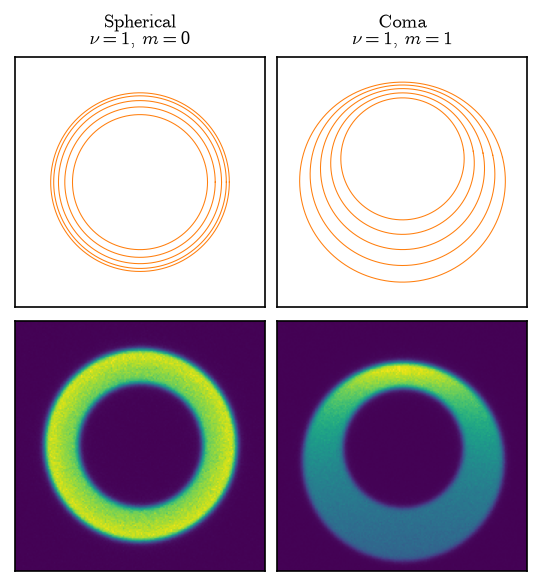

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(3.5, 3.8), constrained_layout=True, dpi=150)

axes[0, 0].set_title("Spherical\n$\\nu = 1,\\, m=0$")
axes[0, 1].set_title("Coma\n$\\nu = 1,\\, m=1$")

# --- Top row: wavefront-circle schematics --------------------------------
# Positive Z11 has W ~ rho^4 - (1 + eps^2) rho^2.  The extra-focal donut is
# upright with respect to the pupil, so the plotted displacement is -grad(W):
# inner and outer rings move toward each other.
EPS = C.EPS_RUBIN
spherical_displacement = lambda rho, theta, m: polar_displacement_to_xy(
    rho, theta, -2 * rho**3 + (1 + EPS**2) * rho, 0
)
map_circles(0.17, 0, spherical_displacement, ax=axes[0, 0])

# Positive Z7 sine coma, dropping the pure-tilt term.  The dominant term shifts
# each ring by an amount proportional to rho^2, decentering the hole relative to
# the outer edge.
COMA_A = 1 + EPS**2
coma_displacement = lambda rho, theta, m: (
    -3 * COMA_A * rho**2 * np.sin(2 * theta),
    3 * COMA_A * rho**2 * np.cos(2 * theta) - 6 * COMA_A * rho**2,
)
map_circles(0.03, 0, coma_displacement, ax=axes[0, 1])

# --- Bottom row: simulated extra-focal donuts ----------------------------
# The image panels use the corresponding positive sine-side Noll coefficients:
# spherical Z11 and coma Z7.
show_donut(axes[1, 0], sim.simulate_donut(zernikes={11: 0.2e-6}))
show_donut(axes[1, 1], sim.simulate_donut(zernikes={7: 2e-6}))

fig.savefig("../figures/abberations_spherical_coma.pdf", bbox_inches="tight")


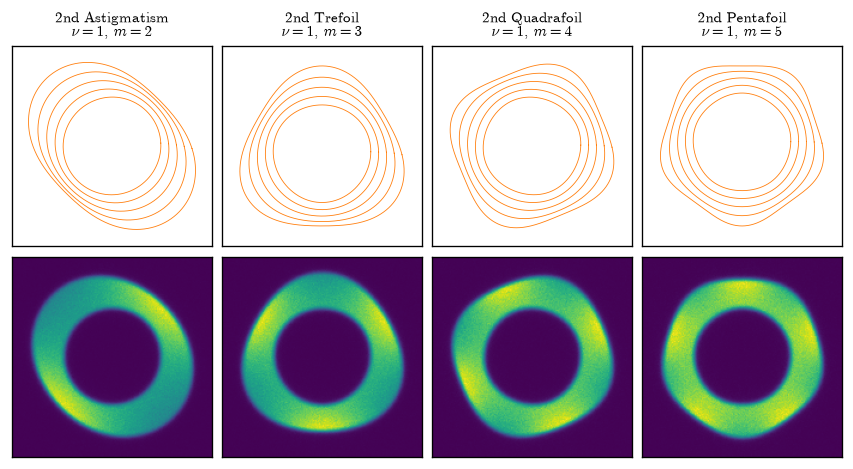

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(7, 3.8), constrained_layout=True, dpi=120)

axes[0, 0].set_title("2nd Astigmatism\n$\\nu = 1,\\, m=2$")
axes[0, 1].set_title("2nd Trefoil\n$\\nu = 1,\\, m=3$")
axes[0, 2].set_title("2nd Quadrafoil\n$\\nu = 1,\\, m=4$")
axes[0, 3].set_title("2nd Pentafoil\n$\\nu = 1,\\, m=5$")

# --- Top row: wavefront-circle schematics --------------------------------
# For the secondary m-foils,
#   W ~ [(m + 2) rho^(m + 2) - (m + 1) A_m rho^m] sin(m theta),
# with A_m set by annular orthogonality.  We again plot -grad(W), converted
# from polar radial/tangential components into Cartesian displacements.
EPS = C.EPS_RUBIN


def secondary_mfoil_displacement(rho, theta, m):
    annular_a = (1 - EPS ** (2 * (m + 2))) / (1 - EPS ** (2 * (m + 1)))
    drho = (
        m * (m + 1) * annular_a * rho ** (m - 1)
        - (m + 2) ** 2 * rho ** (m + 1)
    ) * np.sin(m * theta)
    dtheta = (
        m * (m + 1) * annular_a * rho ** (m - 1)
        - m * (m + 2) * rho ** (m + 1)
    ) * np.cos(m * theta)
    return polar_displacement_to_xy(rho, theta, drho, dtheta)


map_circles(0.018, 2, secondary_mfoil_displacement, ax=axes[0, 0])
map_circles(0.007, 3, secondary_mfoil_displacement, ax=axes[0, 1])
map_circles(0.004, 4, secondary_mfoil_displacement, ax=axes[0, 2])
map_circles(0.0025, 5, secondary_mfoil_displacement, ax=axes[0, 3])

# --- Bottom row: simulated extra-focal donuts ----------------------------
# These are the positive sine-side secondary m-foil modes.  Z25 and Z33 are
# display-only higher-Noll modes, so simulate_donut pads the Zernike vector.
show_donut(axes[1, 0], sim.simulate_donut(zernikes={13: 0.75e-6}))
show_donut(axes[1, 1], sim.simulate_donut(zernikes={19: 0.4e-6}))
show_donut(axes[1, 2], sim.simulate_donut(zernikes={25: 0.22e-6}))
show_donut(axes[1, 3], sim.simulate_donut(zernikes={33: 0.12e-6}))

fig.savefig("../figures/abberations_2nd_astig_mfoil.pdf", bbox_inches="tight")


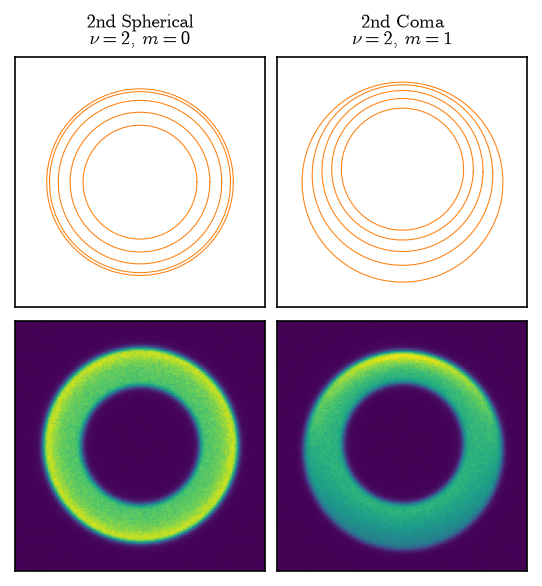

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(3.5, 3.8), constrained_layout=True, dpi=150)

axes[0, 0].set_title("2nd Spherical\n$\\nu = 2,\\, m=0$")
axes[0, 1].set_title("2nd Coma\n$\\nu = 2,\\, m=1$")

# --- Top row: wavefront-circle schematics --------------------------------
# Secondary spherical (Z22): W has rho^6, rho^4, and rho^2 terms.  The plotted
# displacement is -grad(W), with the arbitrary overall normalization absorbed
# into the display amplitude below.
EPS = C.EPS_RUBIN
secondary_spherical_displacement = lambda rho, theta, m: polar_displacement_to_xy(
    rho,
    theta,
    -5 * rho**5
    + 5 * (1 + EPS**2) * rho**3
    - (1 + 3 * EPS**2 + EPS**4) * rho,
    0,
)
map_circles(0.17, 0, secondary_spherical_displacement, ax=axes[0, 0])

# Secondary sine coma (Z17), including the annular low-order term.  That term
# is a global tilt; map_circles recenters the view, leaving the relative
# rho-dependent distortion that matters for the donut shape.
SC_A = 10 * (1 + 4 * EPS**2 + EPS**4)
SC_B = 12 * (1 + 4 * EPS**2 + 4 * EPS**4 + EPS**6)
SC_D = 3 * (1 + 4 * EPS**2 + 10 * EPS**4 + 4 * EPS**6 + EPS**8)


def secondary_coma_displacement(rho, theta, m):
    drho = -(5 * SC_A * rho**4 - 3 * SC_B * rho**2 + SC_D) * np.sin(theta)
    dtheta = -(SC_A * rho**4 - SC_B * rho**2 + SC_D) * np.cos(theta)
    return polar_displacement_to_xy(rho, theta, drho, dtheta)


map_circles(0.003, 0, secondary_coma_displacement, ax=axes[0, 1])

# --- Bottom row: simulated extra-focal donuts ----------------------------
# The image panels use the corresponding positive Noll coefficients: secondary
# spherical Z22 and sine secondary coma Z17.
show_donut(axes[1, 0], sim.simulate_donut(zernikes={22: 0.05e-6}))
show_donut(axes[1, 1], sim.simulate_donut(zernikes={17: 0.2e-6}))

fig.savefig("../figures/abberations_2nd_spherical_coma.pdf", bbox_inches="tight")
